In [ ]:
import pandas as pd
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam
from sklearn.preprocessing import StandardScaler


In [ ]:
Dataset = pd.read_excel("../Dados/Dados.xlsx")

Datasets = []

for n in range(1, 5):
    n_data = Dataset[ Dataset["Pontos"] == f"P{n}"]
    n_data = n_data.drop(columns=["Campanhas", "Pontos"])
    
    n_data_norm = n_data
        
    Datasets.append(n_data)

In [ ]:
PREDICTORS = ["pH", "Cond", "Temp", "OD", "Tds", "Resist", "Salin", "ORP", "IP", "Cor"] # 10 entradas
TARGETS = ["Fe", "Al", "As", "Pb", "Zn", "Hg", "Co", "V", "Ba", "Mn"] # 10 saidas

SCALER = StandardScaler()
OUT_SCALER = StandardScaler()

N_COMPONENTS = 6

In [ ]:
import matplotlib.pyplot as plt
import os

def PlotPredictions(train_orig, train_pred, test_orig, test_pred, target_name, n): 
    # cria figura
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # -----------------------------
    # SUBPLOT 1 — TREINO
    # -----------------------------
    ax = axes[0]
    n_train = len(train_orig)
    x_train = np.arange(n_train)

    ax.plot(x_train, train_orig, label="Original (train)", color="blue", )
    ax.plot(x_train, train_pred, label="Predito (train)", color="red",)

    ax.scatter(x_train, train_orig, color="blue", s=35)
    ax.scatter(x_train, train_pred, color="red", s=35)

    ax.set_title("Treinamento")
    ax.set_xlabel("Amostras")
    ax.set_ylabel(target_name)
    ax.grid(True)
    ax.legend()

    # -----------------------------
    # SUBPLOT 2 — TESTE
    # -----------------------------
    ax = axes[1]
    n_test = len(test_orig)
    x_test = np.arange(n_test)

    ax.plot(x_test, test_orig, label="Original (test)", color="blue", linewidth=1.8)
    ax.plot(x_test, test_pred, label="Predito (test)", color="red", linewidth=1.8)

    ax.scatter(x_test, test_orig, color="blue", s=35)
    ax.scatter(x_test, test_pred, color="red", s=35)

    ax.set_title("Teste")
    ax.set_xlabel("Amostras")
    ax.set_ylabel(target_name)
    ax.grid(True)
    ax.legend()

    plt.tight_layout()

    # # salva a figura
    # filename = f"./Dados/VirtualData/P{n}/TrainResults/{target_name}.pdf"
    # plt.savefig(filename, format="pdf", bbox_inches="tight")

    # # fecha a figura (IMPORTANTE para não acumular memória)
    # plt.close(fig)

    # print(f"Figura salva em: {filename}")


In [ ]:
from sklearn.model_selection import train_test_split


def PrepareData(VirtualDataset, OriginalDataset, target, vs=False):
    X_orig = OriginalDataset[PREDICTORS].values
    Y_orig = OriginalDataset[target].values
    
    X_train, X_test, Y_train, Y_test = train_test_split(
    X_orig, Y_orig, test_size=0.2, random_state=42)
    
    if vs == True:
        Xv = VirtualDataset[PREDICTORS].values
        Yv = VirtualDataset[target].values
        
        # CONCATENAÇÃO CORRETA
        X_train = np.concatenate((X_train, Xv), axis=0)
        Y_train = np.concatenate((Y_train, Yv), axis=0)
        
    x_train = SCALER.fit_transform(X_train)
    x_test  = SCALER.transform(X_test)
    
    return x_train, x_test, Y_train, Y_test

    
def PrintDim(x, y):
    print(f"Dimensão da entrada: {np.shape(x)}")
    print(f"Dimensão da saida: {np.shape(y)}")

In [ ]:
def RebuildAndForward(P, runTime, target, neurons,
                      use_virtual=True,
                      results_vs="Results-vs.xlsx",
                      results_no_vs="Results-no-vs.xlsx"):

    # -------------------------------------------------
    # 1) Escolha do arquivo conforme a origem
    # -------------------------------------------------
    results_file = results_vs if use_virtual else results_no_vs
    df = pd.read_excel(results_file)

    row = df[
        (df["P"] == P) &
        (df["runTime"] == runTime) &
        (df["target"] == target) &
        (df["neurons"] == neurons)
    ]

    if row.empty:
        raise ValueError("Modelo não encontrado para esses parâmetros.")

    row = row.iloc[0]

    n_hidden = [int(row["neurons"])]
    Wf = eval(row["Wf"])
    Wf = [np.array(w) for w in Wf]

    # -------------------------------------------------
    # 2) Recriar dados
    # -------------------------------------------------
    Dataset = Datasets[P-1]

    if use_virtual:
        output_dir = f"./Dados/VirtualData/P{P}"
        vs_filename = os.path.join(output_dir, f"virtual_samples_{target}.xlsx")
        VirtualDataset = pd.read_excel(vs_filename, sheet_name="orig-vs")

        x_train, x_test, y_train, y_test = PrepareData(
            VirtualDataset, Dataset, target, vs=True
        )
    else:
        x_train, x_test, y_train, y_test = PrepareData(
            None, Dataset, target
        )

    y_train = OUT_SCALER.fit_transform(y_train.reshape(-1, 1)).ravel()
    y_test  = OUT_SCALER.transform(y_test.reshape(-1, 1)).ravel()

    # -------------------------------------------------
    # 3) Reconstruir o modelo
    # -------------------------------------------------
    n_inputs = x_train.shape[1]

    model = Sequential()
    model.add(Dense(
        n_hidden[0],
        activation="relu",
        kernel_regularizer=l2(1e-4),
        input_shape=(n_inputs,)
    ))
    model.add(Dense(1, activation="linear"))
    model.compile(optimizer=Adam(1e-3), loss="mse")

    model.set_weights(Wf)

    # -------------------------------------------------
    # 4) Forward
    # -------------------------------------------------
    y_train_pred_norm = model.predict(x_train, verbose=0)
    y_test_pred_norm  = model.predict(x_test,  verbose=0)

    y_train_real = OUT_SCALER.inverse_transform(y_train.reshape(-1, 1)).ravel()
    y_test_real  = OUT_SCALER.inverse_transform(y_test.reshape(-1, 1)).ravel()

    y_train_pred = OUT_SCALER.inverse_transform(y_train_pred_norm).ravel()
    y_test_pred  = OUT_SCALER.inverse_transform(y_test_pred_norm).ravel()

    # -------------------------------------------------
    # 5) Plot
    # -------------------------------------------------
    PlotPredictions(
        y_train_real, y_train_pred,
        y_test_real,  y_test_pred,
        target_name=target,
        n=P
    )
    return model

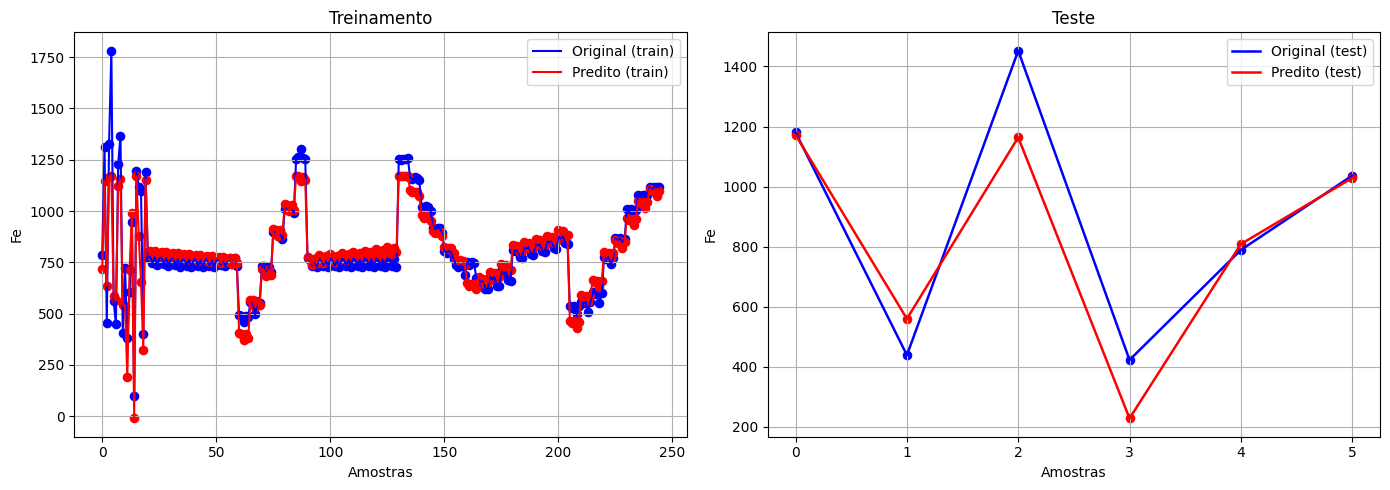

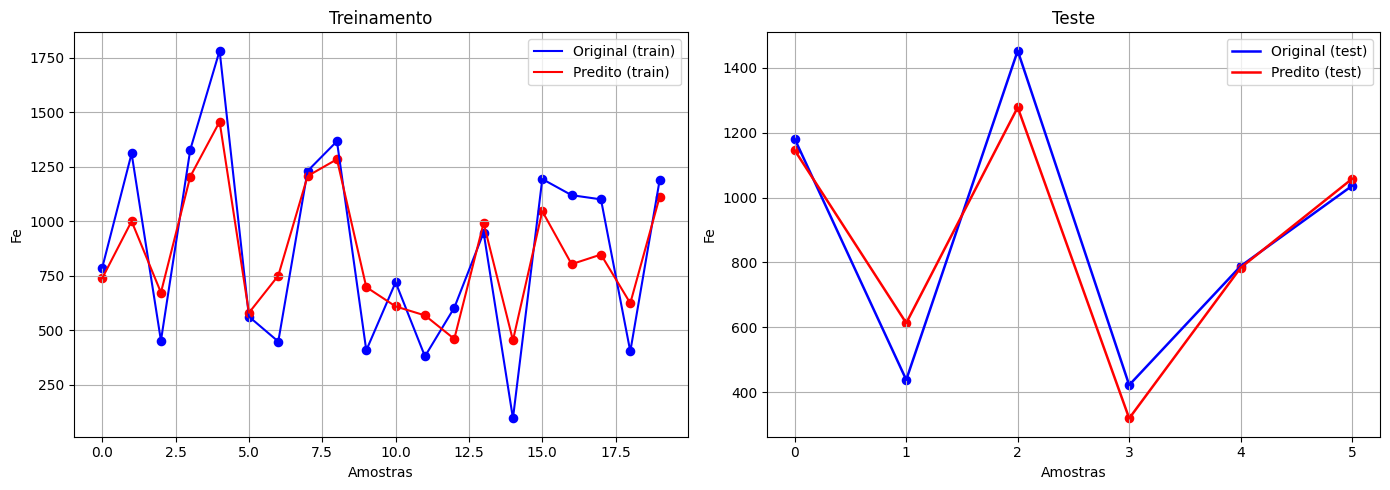

In [ ]:
# modelo treinado com dados virtuais
RebuildAndForward(P=5, runTime=0, target="Fe", neurons=16, use_virtual=True)

# modelo treinado apenas com dados reais
RebuildAndForward(P=5, runTime=3, target="Fe", neurons=2, use_virtual=False)
